# After Prophet: the response model and the scenario engine

Prophet's job ends when every driver has a forward path. This notebook picks up
there and walks through the two pieces that turn those driver paths into a volume
forecast you can interrogate:

1. **`src/features.py` + `src/model.py`** — how a panel of drivers becomes a design
   matrix, and how the pooled sign-constrained log-log ridge is fitted.
2. **`src/scenario.py`** — how a slider move becomes a volume delta, and how that
   delta is attributed back to individual drivers.

Every number below is recomputed from the artifacts in `data/` and `artifacts/`.
Run `python scripts/build.py` first if they're missing.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
warnings.filterwarnings("ignore")

import config
from src import features, model, scenario as scen, data_gen

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# Chart styling: recessive grid, ink-coloured text, fixed categorical hues.
BLUE, ORANGE, AQUA, YELLOW = config.SERIES[0], config.SERIES[1], config.SERIES[2], config.SERIES[3]
plt.rcParams.update({
    "figure.facecolor": config.SURFACE, "axes.facecolor": config.SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": config.INK_SECONDARY,
    "axes.grid": True, "grid.color": config.GRIDLINE, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": config.INK_MUTED, "ytick.color": config.INK_MUTED,
    "text.color": config.INK_SECONDARY, "font.size": 10, "figure.dpi": 110,
})

panel = pd.read_csv(config.PANEL_CSV, parse_dates=["date"])
driver_fc = pd.read_csv(config.DRIVER_FORECAST_CSV, parse_dates=["date"])
m = model.ResponseModel.load()
metrics = json.loads(config.METRICS_JSON.read_text())

print(f"panel        {panel.shape}  {panel['date'].min():%Y-%m} -> {panel['date'].max():%Y-%m}")
print(f"driver_fc    {driver_fc.shape}  {driver_fc['date'].min():%Y-%m} -> {driver_fc['date'].max():%Y-%m}")
print(f"drivers      {len(config.DRIVER_NAMES)}  |  categories {len(config.CATEGORIES)}")

panel        (330, 12)  2021-01 -> 2026-06
driver_fc    (90, 11)  2026-07 -> 2027-12
drivers      9  |  categories 5


---
# Part 1 — From drivers to a design matrix

`src/features.py` is the seam that both the synthetic generator and the model
import. That's deliberate: the transform used to *create* the data is by
construction the same one used to *fit* it, so the two can't silently disagree.

Three things happen, in order: **adstock → log → assemble**.

In [2]:
panel.head(3)

,date,category,volume,avg_price,distribution_acv,promo_depth,promo_share,media_spend,cpi_food,consumer_confidence,unemployment_rate,avg_temp_c
0,2021-01-01,Beverages,1036652.0,2.989800,71.938136,17.447734,29.958208,120.250252,100.262447,98.597897,6.799616,3.041770
1,2021-02-01,Beverages,1618220.0,2.921831,72.770464,19.129773,31.741227,131.216345,99.925698,97.214313,6.074504,4.810926
2,2021-03-01,Beverages,1451689.0,2.979812,72.502025,15.652733,31.554195,97.952941,100.363458,96.741762,6.046535,7.674098


## 1.1 Adstock — media doesn't spend and vanish

A TV burst in March still sells product in April. `geometric_adstock` carries a
fraction of each month's spend forward:

$$a_t = x_t + \lambda \, a_{t-1}, \qquad \lambda = 0.45$$

This is applied **before** the log, and only to drivers with an `adstock` key in
`config.DRIVERS` — currently just `media_spend`.

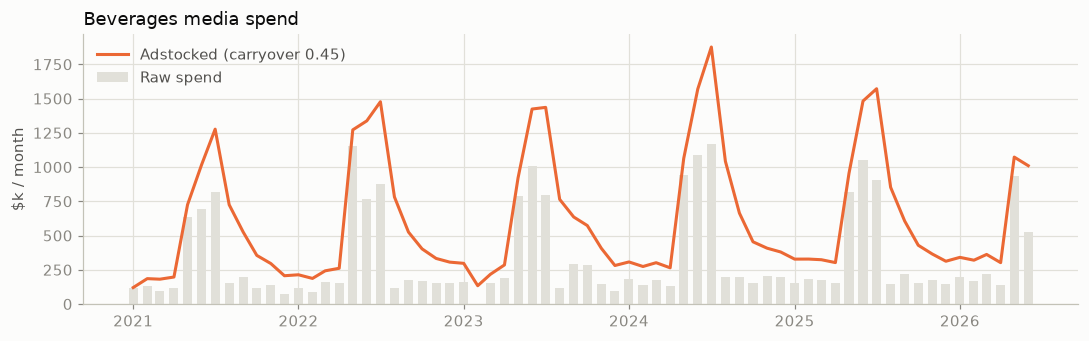

raw total           22,667
adstocked total     40,386   (~1/(1-0.45) = 1.82x the raw level)

A dark month still carries value from the month before:
  2023-02: raw=0  adstocked=133.7  (from 159 the prior month)


In [3]:
bev = panel[panel["category"] == "Beverages"].sort_values("date").reset_index(drop=True)
raw = bev["media_spend"].to_numpy()
ads = features.geometric_adstock(raw, config.DRIVERS["media_spend"]["adstock"])

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(bev["date"], raw, width=20, color=config.GRIDLINE, label="Raw spend")
ax.plot(bev["date"], ads, color=ORANGE, lw=2, label="Adstocked (carryover 0.45)")
ax.set_ylabel("$k / month"); ax.set_title("Beverages media spend", color=config.INK_PRIMARY, loc="left")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

print(f"raw total       {raw.sum():>10,.0f}")
print(f"adstocked total {ads.sum():>10,.0f}   (~1/(1-0.45) = {1/(1-0.45):.2f}x the raw level)")
print("\nA dark month still carries value from the month before:")
dark = np.where(raw == 0)[0]
if len(dark):
    i = dark[0]
    print(f"  {bev['date'][i]:%Y-%m}: raw={raw[i]:.0f}  adstocked={ads[i]:.1f}  (from {raw[i-1]:.0f} the prior month)")

## 1.2 The log transform — and why log-log

Each driver is mapped to log space. `log` for strictly-positive quantities,
`log1p` for anything that can legitimately be zero (media spend, promo depth).

The reason the whole model is log-log is **interpretation**. With

$$\log V = \alpha + \beta \log P + \dots$$

$\beta$ is an elasticity: the % change in volume per 1% change in price. That's
the unit a category manager already thinks in, and it makes driver effects
multiplicative rather than additive — a 10% price cut means the same thing
whether the category sells 1M or 3M units.

In [4]:
for name, spec in config.DRIVERS.items():
    print(f"  {name:22s} {spec['transform']:6s}  sign={spec['sign']:+d}  range "
          f"[{panel[name].min():>8.2f}, {panel[name].max():>8.2f}]")

  avg_price              log     sign=-1  range [    2.55,     8.54]
  distribution_acv       log     sign=+1  range [   55.96,    94.28]
  promo_depth            log1p   sign=+1  range [    7.11,    30.86]
  promo_share            log1p   sign=+1  range [   12.10,    65.46]
  media_spend            log1p   sign=+1  range [    0.00,  1170.06]
  cpi_food               log     sign=-1  range [   99.93,   125.98]
  consumer_confidence    log     sign=+1  range [   74.24,   109.02]
  unemployment_rate      log     sign=-1  range [    3.63,     6.80]
  avg_temp_c             log     sign=+0  range [    1.44,    26.34]


## 1.3 The assembled design matrix

`build_design` returns log drivers + a linear trend + category fixed effects +
month-of-year dummies. The fixed effects are what make **pooling** work: one
model across all five categories, with the FE absorbing the level differences
(Dairy sells 3.1M units/month, Household Care 950k) so the shared elasticities
are estimated off *within-category variation*, not the gap between categories.

Both dummy sets drop their first level (Beverages, January) to avoid perfect
collinearity with the intercept.

In [5]:
t0 = pd.Timestamp(config.HISTORY_START)
X = features.build_design(panel, t0)

print(f"design matrix: {X.shape[0]} rows x {X.shape[1]} columns\n")
print(f"  {len(features.LOG_COLS):>2d} log drivers      {features.LOG_COLS[:3]} ...")
print(f"  {1:>2d} trend            ['trend']  (years since {config.HISTORY_START[:7]})")
print(f"  {len(config.CATEGORIES)-1:>2d} category FE      {[c for c in X.columns if c.startswith('cat_')][:2]} ...")
print(f"  {11:>2d} month FE         ['mon_2', 'mon_3'] ...")
X.iloc[:3, :6].round(3)

design matrix: 330 rows x 25 columns

   9 log drivers      ['l_avg_price', 'l_distribution_acv', 'l_promo_depth'] ...
   1 trend            ['trend']  (years since 2021-01)
   4 category FE      ['cat_Snacks', 'cat_Dairy'] ...
  11 month FE         ['mon_2', 'mon_3'] ...


,l_avg_price,l_distribution_acv,l_promo_depth,l_promo_share,l_media_spend,l_cpi_food
0,1.095,4.276,2.915,3.433,4.798,4.608
1,1.072,4.287,3.002,3.489,5.228,4.604
2,1.092,4.284,2.813,3.483,5.206,4.609


---
# Part 2 — Why ridge, and why sign constraints

Two problems in this data force the model choice. Neither is exotic; both show up
in almost every real category dataset.

## 2.1 The drivers are entangled

Average price **is** list price net of promotion — that's an accounting identity
in the generator, and it's true of real scanner data too:

$$\text{avg price} = \text{list price} \times (1 - \text{promo share} \times \text{promo depth})$$

So price, promo depth and promo share move together mechanically. Ridge doesn't
"solve" collinearity — it manages it, trading a little bias for a large variance
reduction so the coefficients stop swinging wildly.

In [6]:
L = X[features.LOG_COLS + ["trend"]]
corr = L.corr()

pairs = [(corr.index[i], corr.columns[j], corr.iloc[i, j])
         for i in range(len(corr)) for j in range(i+1, len(corr))
         if abs(corr.iloc[i, j]) > 0.6]
print("Correlations above |0.6|:")
for a, b, v in sorted(pairs, key=lambda p: -abs(p[2])):
    flag = "  <-- barely identifiable" if abs(v) > 0.95 else ""
    print(f"  {a:24s} {b:24s} {v:+.3f}{flag}")

Z = (L - L.mean()) / L.std()
vif = pd.Series(np.diag(np.linalg.inv(np.corrcoef(Z.T))), index=L.columns)
print("\nVIF (>5 = meaningful collinearity, >10 = severe):")
print(vif.round(1).sort_values(ascending=False).to_string())

Correlations above |0.6|:
  l_cpi_food               trend                    +0.963  <-- barely identifiable
  l_promo_depth            l_promo_share            +0.889
  l_cpi_food               l_unemployment_rate      -0.730
  l_consumer_confidence    trend                    +0.629
  l_unemployment_rate      trend                    -0.628

VIF (>5 = meaningful collinearity, >10 = severe):
l_cpi_food               23.3
trend                    19.3
l_distribution_acv        8.3
l_promo_depth             5.5
l_promo_share             5.1
l_avg_price               4.1
l_unemployment_rate       3.7
l_consumer_confidence     2.8
l_media_spend             1.5
l_avg_temp_c              1.0


## 2.2 The identification failure: CPI vs the trend

`l_cpi_food` correlates **0.963** with the time trend and carries a VIF of 23.3.
Food CPI in this data rises almost monotonically — so does `trend`. The regression
genuinely cannot separate the two, which means the coefficient it reports depends
heavily on how much shrinkage is applied.

Watch it across alphas below. At near-OLS the CPI elasticity comes back
**positive** — food inflation raising volume — and only shrinkage pulls it back.

In [7]:
from sklearn.linear_model import Ridge as PlainRidge
from sklearn.preprocessing import StandardScaler

Xn = X[features.DESIGN_COLS]
y = np.log(panel["volume"].to_numpy())
sc = StandardScaler().fit(Xn[features.NUM_COLS])
Xs = Xn.copy(); Xs[features.NUM_COLS] = sc.transform(Xn[features.NUM_COLS])

rows = []
for a in [0.0001, 0.05, 10.0]:
    r = PlainRidge(alpha=a).fit(Xs, y)
    e = pd.Series(r.coef_[:len(features.NUM_COLS)] / sc.scale_, index=features.NUM_COLS)
    rows.append(pd.Series({n: e[f"l_{n}"] for n in config.DRIVER_NAMES}, name=f"alpha={a}"))

cmp = pd.DataFrame(rows).T
cmp["CONSTRAINED (shipped)"] = m.elasticities
cmp["expected sign"] = [config.DRIVERS[n]["sign"] for n in cmp.index]
print("Unconstrained ridge at three alphas vs the shipped model:\n")
print(cmp.round(3).to_string())

bad = [n for n in config.DRIVER_NAMES
       if config.DRIVERS[n]["sign"] and np.sign(cmp.loc[n, "alpha=0.0001"]) != config.DRIVERS[n]["sign"]]
print(f"\nWrong-signed drivers in the near-OLS fit: {bad}")

Unconstrained ridge at three alphas vs the shipped model:

                     alpha=0.0001  alpha=0.05  alpha=10.0  CONSTRAINED (shipped)  expected sign
avg_price                  -2.914      -1.715      -0.770                 -1.715             -1
distribution_acv            1.267       1.237       1.329                  1.237              1
promo_depth                 0.568       0.612       0.153                  0.612              1
promo_share                 0.228       0.294       0.099                  0.294              1
media_spend                 0.123       0.123       0.097                  0.123              1
cpi_food                    0.409      -0.520      -0.944                 -0.520             -1
consumer_confidence         0.465       0.485       0.470                  0.485              1
unemployment_rate          -0.167      -0.172      -0.161                 -0.172             -1
avg_temp_c                  0.203       0.199       0.227                  0.

## 2.3 `SignedRidge` — ridge with a business prior

The fix is to pin known-sign drivers to their sign. `SignedRidge` solves ridge as
a **bounded** least-squares problem on the Tikhonov-augmented system:

$$\begin{bmatrix} X_c \\ \sqrt{\alpha} I \end{bmatrix} b
  \;\approx\; \begin{bmatrix} y_c \\ 0 \end{bmatrix},
  \qquad \text{s.t.} \quad l_j \le b_j \le u_j$$

Stacking $\sqrt{\alpha}I$ under $X$ is exactly equivalent to the ridge penalty —
so with infinite bounds it reproduces sklearn's `Ridge` to machine precision.
Centring both sides first means the intercept is fitted but never penalised or
constrained. Fixed effects and the trend stay free; only log drivers with a
non-zero `sign` get bounded.

In [8]:
# The augmented system really is ridge: unconstrained SignedRidge == sklearn Ridge.
free = model.SignedRidge(alpha=0.05, bounds=None).fit(Xs.to_numpy(), y)
sk = PlainRidge(alpha=0.05).fit(Xs, y)
print(f"max |coef difference| vs sklearn Ridge: {np.abs(free.coef_ - sk.coef_).max():.2e}")
print(f"intercept difference:                   {abs(free.intercept_ - sk.intercept_):.2e}")

lo, hi = model._coef_bounds()
b = pd.DataFrame({"column": features.DESIGN_COLS, "lower": lo, "upper": hi})
print("\nBounds actually applied (unbounded rows hidden):")
print(b[np.isfinite(b["lower"]) | np.isfinite(b["upper"])].to_string(index=False))

max |coef difference| vs sklearn Ridge: 2.00e-14
intercept difference:                   1.60e-14

Bounds actually applied (unbounded rows hidden):
               column  lower  upper
          l_avg_price   -inf    0.0
   l_distribution_acv    0.0    inf
        l_promo_depth    0.0    inf
        l_promo_share    0.0    inf
        l_media_spend    0.0    inf
           l_cpi_food   -inf    0.0
l_consumer_confidence    0.0    inf
  l_unemployment_rate   -inf    0.0


### Does the constraint actually bind?

Worth checking honestly rather than assuming — and the answer is **no, not at the
shipped alpha**. CV selects `alpha=0.05`, and at that level shrinkage alone is
already enough to hold CPI at −0.52. Every constrained estimate matches the
unconstrained one to four decimals: **zero of nine bounds are active**.

So the constraint is *insurance*, not a live correction. It costs nothing here,
and it guarantees that if the data shifts — or if CV lands on a smaller alpha,
where the unconstrained fit does flip CPI positive (+0.41 at `alpha=0.0001`) — a
slider can never invert on a driver whose direction isn't genuinely in question.
For a tool whose entire purpose is answering "what if I move this?", that's a
cheap guarantee.

In [9]:
uncon = PlainRidge(alpha=metrics["alpha"]).fit(Xs, y)
ue = pd.Series(uncon.coef_[:len(features.NUM_COLS)] / sc.scale_, index=features.NUM_COLS)
side = pd.DataFrame({
    "unconstrained": [ue[f"l_{n}"] for n in config.DRIVER_NAMES],
    "constrained":   [m.elasticities[n] for n in config.DRIVER_NAMES],
}, index=config.DRIVER_NAMES)
side["diff"] = side["constrained"] - side["unconstrained"]
side["binding"] = side["diff"].abs() > 1e-4
print(side.round(4).to_string())
print(f"\nBinding constraints: {int(side['binding'].sum())} of {len(side)}")

                     unconstrained  constrained  diff  binding
avg_price                  -1.7149      -1.7149   0.0    False
distribution_acv            1.2373       1.2373  -0.0    False
promo_depth                 0.6121       0.6121   0.0    False
promo_share                 0.2936       0.2936   0.0    False
media_spend                 0.1226       0.1226  -0.0    False
cpi_food                   -0.5199      -0.5199   0.0    False
consumer_confidence         0.4854       0.4854   0.0    False
unemployment_rate          -0.1724      -0.1724   0.0    False
avg_temp_c                  0.1989       0.1989   0.0    False

Binding constraints: 0 of 9


---
# Part 3 — Fitting

## 3.1 Cross-validation cut on dates, not rows

This is a panel: each date appears five times, once per category. A random KFold
would put Beverages-March-2024 in training and Dairy-March-2024 in validation —
leaking the month's macro conditions across the split and flattering the score.

`_time_folds` cuts on **unique dates** with an expanding window, so validation is
always strictly in the future of training.

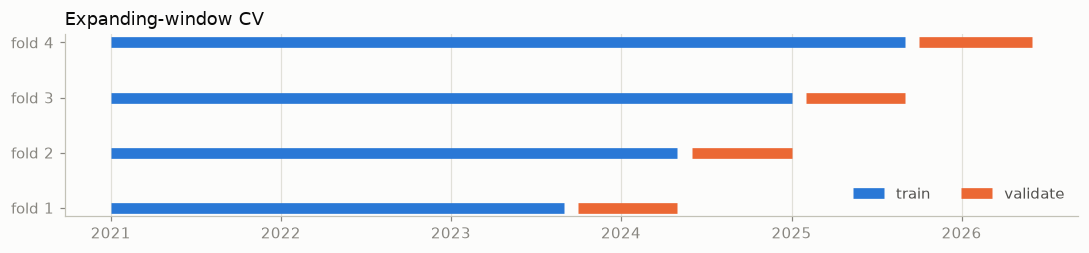

  fold 1: train 2021-01..2023-09 (165 rows)   validate 2023-10..2024-05 (40 rows)
  fold 2: train 2021-01..2024-05 (205 rows)   validate 2024-06..2025-01 (40 rows)
  fold 3: train 2021-01..2025-01 (245 rows)   validate 2025-02..2025-09 (40 rows)
  fold 4: train 2021-01..2025-09 (285 rows)   validate 2025-10..2026-06 (45 rows)


In [10]:
folds = list(model._time_folds(panel["date"]))
dates = panel["date"]

fig, ax = plt.subplots(figsize=(10, 2.4))
for k, (tr, te) in enumerate(folds):
    ax.plot([dates.iloc[tr].min(), dates.iloc[tr].max()], [k, k], lw=7, color=BLUE,
            solid_capstyle="butt", label="train" if k == 0 else None)
    ax.plot([dates.iloc[te].min(), dates.iloc[te].max()], [k, k], lw=7, color=ORANGE,
            solid_capstyle="butt", label="validate" if k == 0 else None)
ax.set_yticks(range(len(folds))); ax.set_yticklabels([f"fold {i+1}" for i in range(len(folds))])
ax.set_title("Expanding-window CV", color=config.INK_PRIMARY, loc="left")
ax.grid(axis="y", visible=False); ax.legend(frameon=False, ncol=2); plt.tight_layout(); plt.show()

for k, (tr, te) in enumerate(folds):
    print(f"  fold {k+1}: train {dates.iloc[tr].min():%Y-%m}..{dates.iloc[tr].max():%Y-%m} "
          f"({len(tr):>3d} rows)   validate {dates.iloc[te].min():%Y-%m}..{dates.iloc[te].max():%Y-%m} ({len(te)} rows)")

## 3.2 Choosing alpha

Alpha is picked by grid search over those folds. The curve is shallow in the
middle — anywhere from 0.01 to 0.5 performs about the same — but it degrades
sharply once shrinkage starts crushing the real signal.

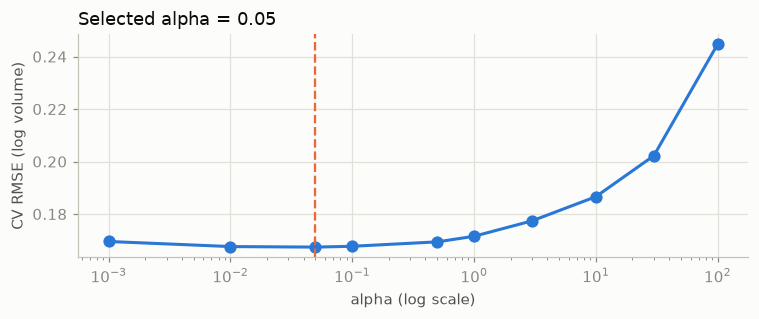

  alpha  cv_rmse
  0.001   0.1695
  0.010   0.1676
  0.050   0.1674
  0.100   0.1677
  0.500   0.1694
  1.000   0.1715
  3.000   0.1774
 10.000   0.1866
 30.000   0.2022
100.000   0.2447


In [11]:
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(model._pipeline(), {"ridge__alpha": config.RIDGE_ALPHAS},
                  cv=folds, scoring="neg_mean_squared_error").fit(Xn, y)

cv = pd.DataFrame({"alpha": config.RIDGE_ALPHAS,
                   "cv_rmse": np.sqrt(-gs.cv_results_["mean_test_score"])})
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(cv["alpha"], cv["cv_rmse"], "o-", color=BLUE, lw=2, ms=7)
ax.axvline(gs.best_params_["ridge__alpha"], color=ORANGE, ls="--", lw=1.5)
ax.set_xlabel("alpha (log scale)"); ax.set_ylabel("CV RMSE (log volume)")
ax.set_title(f"Selected alpha = {gs.best_params_['ridge__alpha']}", color=config.INK_PRIMARY, loc="left")
plt.tight_layout(); plt.show()
print(cv.round(4).to_string(index=False))

## 3.3 Recovering elasticities from scaled coefficients

The pipeline standardises the numeric columns before fitting (ridge penalises
large coefficients, so unscaled features would be penalised unevenly — a driver
measured in $k would be shrunk differently from one measured in %).

That means the fitted coefficients live in *scaled* space. To read them as
elasticities, divide by the scaler's scale:

$$\beta^{\text{raw}}_j = \beta^{\text{scaled}}_j \big/ \sigma_j$$

Since `StandardScaler` scales are strictly positive, this never changes a sign —
which is why bounding the scaled coefficient validly bounds the elasticity.

In [12]:
scaler = m.pipe.named_steps["pre"].named_transformers_["num"]
coef = m.pipe.named_steps["ridge"].coef_

unscaled = coef[:len(features.NUM_COLS)] / scaler.scale_
out = pd.DataFrame({
    "scaled coef": coef[:len(features.NUM_COLS)],
    "scaler sigma": scaler.scale_,
    "elasticity": unscaled,
}, index=features.NUM_COLS)
print(out.round(4).to_string())
print(f"\nmatches m.elasticities: "
      f"{np.allclose([unscaled[i] for i in range(len(config.DRIVER_NAMES))], m.elasticities.values)}")

                       scaled coef  scaler sigma  elasticity
l_avg_price                -0.6222        0.3629     -1.7149
l_distribution_acv          0.1472        0.1190      1.2373
l_promo_depth               0.1805        0.2949      0.6121
l_promo_share               0.1020        0.3475      0.2936
l_media_spend               0.0907        0.7399      0.1226
l_cpi_food                 -0.0395        0.0760     -0.5199
l_consumer_confidence       0.0542        0.1116      0.4854
l_unemployment_rate        -0.0227        0.1316     -0.1724
l_avg_temp_c                0.1619        0.8141      0.1989
trend                       0.0034        1.5875      0.0021

matches m.elasticities: True


## 3.4 Did it recover the truth?

Because the data is synthetic, the generating elasticities are known. The pooled
model estimates **one** number per driver while the generator gave each category
its own (jittered ±15%), so the fair comparison is against the mean.

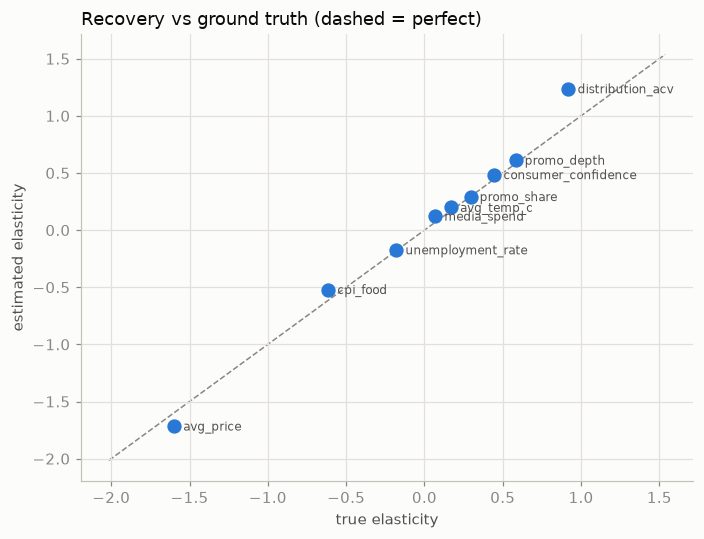

                     estimated   true  error  sign ok
avg_price               -1.715 -1.598 -0.117     True
distribution_acv         1.237  0.920  0.317     True
promo_depth              0.612  0.582  0.030     True
promo_share              0.294  0.294 -0.001     True
media_spend              0.123  0.068  0.054     True
cpi_food                -0.520 -0.615  0.095     True
consumer_confidence      0.485  0.446  0.039     True
unemployment_rate       -0.172 -0.180  0.007     True
avg_temp_c               0.199  0.169  0.030     True


In [13]:
truth = data_gen.true_elasticity_table().set_index("driver")["true_elasticity"]
rec = pd.DataFrame({"estimated": m.elasticities, "true": truth})
rec["error"] = rec["estimated"] - rec["true"]
rec["sign ok"] = np.sign(rec["estimated"]) == np.sign(rec["true"])

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(rec["true"], rec["estimated"], s=70, color=BLUE, zorder=3)
lim = [rec.min().min() - 0.3, rec.max().max() + 0.3]
ax.plot(lim, lim, ls="--", lw=1, color=config.INK_MUTED, zorder=1)
for n, r in rec.iterrows():
    ax.annotate(n, (r["true"], r["estimated"]), fontsize=8,
                xytext=(6, -3), textcoords="offset points", color=config.INK_SECONDARY)
ax.set_xlabel("true elasticity"); ax.set_ylabel("estimated elasticity")
ax.set_title("Recovery vs ground truth (dashed = perfect)", color=config.INK_PRIMARY, loc="left")
plt.tight_layout(); plt.show()
print(rec.round(3).to_string())

## 3.5 Where the model is wrong

In-sample R² of 0.921 sounds strong, but the honest question is how much of the
remaining error is *irreducible*. The generator injects a persistent AR(1) latent
factor (the "measures we don't track") plus iid noise, which together put a floor
of roughly **4.4% MAPE** under any model.

The realised holdout MAPE is 13.6% — so most of the gap is model limitation, not
noise. The residuals say exactly where it lives.

irreducible sd (latent + noise): 0.0550  ->  ~4.4% MAPE floor
actual residual sd:              0.1556

                 mean    std  holdout MAPE %  temp elasticity (true)  pooled estimate
category                                                                             
Beverages       0.002  0.229          20.750                    0.42            0.199
Dairy          -0.000  0.090           7.442                     NaN            0.199
Frozen Foods   -0.000  0.116          11.094                    0.24            0.199
Household Care -0.001  0.209          22.178                   -0.02            0.199
Snacks         -0.001  0.072           6.320                     NaN            0.199


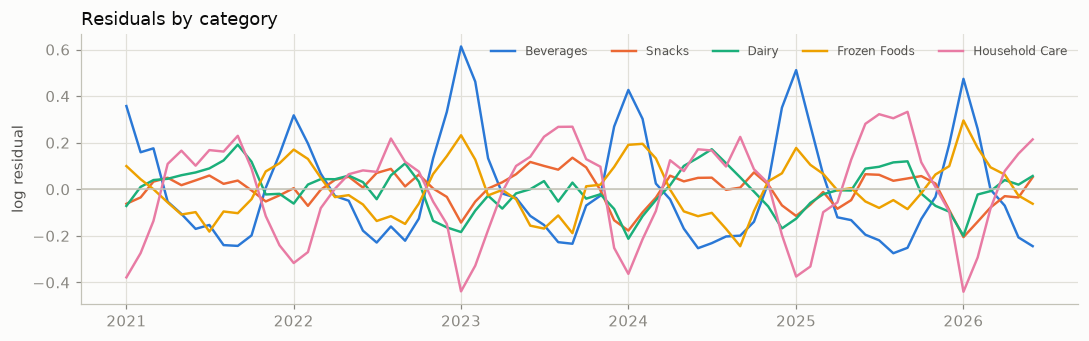

In [14]:
fit = scen.fitted_history(m, panel)
fit["res"] = np.log(fit["fitted"] / fit["volume"])

floor = np.sqrt((config.LATENT_SHOCK_SD / np.sqrt(1 - 0.72**2))**2 + config.NOISE_SD**2)
print(f"irreducible sd (latent + noise): {floor:.4f}  ->  ~{100*floor*0.8:.1f}% MAPE floor")
print(f"actual residual sd:              {fit['res'].std():.4f}\n")

by = fit.groupby("category")["res"].agg(["mean", "std"])
by["holdout MAPE %"] = pd.Series(metrics["holdout"]["by_category"])
by["temp elasticity (true)"] = pd.Series(
    {"Beverages": 0.42, "Frozen Foods": 0.24, "Household Care": -0.02, "Dairy": None, "Snacks": None})
by["pooled estimate"] = m.elasticities["avg_temp_c"]
print(by.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 3.2))
for i, c in enumerate(config.CATEGORIES):
    s = fit[fit["category"] == c]
    ax.plot(s["date"], s["res"], lw=1.6, color=config.SERIES[i], label=c)
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_ylabel("log residual"); ax.legend(frameon=False, ncol=5, fontsize=8)
ax.set_title("Residuals by category", color=config.INK_PRIMARY, loc="left")
plt.tight_layout(); plt.show()

**Read that table carefully — it's the main caveat on this model.** Beverages and
Household Care have residual sd roughly 2.5x Dairy and Snacks, and they're exactly
the two categories whose true temperature elasticity is furthest from the pooled
estimate (+0.42 and −0.02 against a pooled +0.20). A single elasticity per driver
cannot represent a category that loves heat and one that ignores it.

That's the cost of pooling, and it's the obvious next iteration: category × driver
interactions on the drivers that genuinely differ, or a hierarchical model that
shrinks per-category elasticities toward a global mean.

---
# Part 4 — Reading the fitted model

## 4.1 Elasticity to percentage change — the trap

An elasticity is a *log-log* slope, so you cannot multiply it by a percentage.
The correct conversion is:

$$\frac{\Delta V}{V} = \left(1 + \frac{\Delta x}{x}\right)^{\beta} - 1
= e^{\,\beta \ln(1 + \Delta x / x)} - 1$$

For small moves the naive `beta x pct` is close enough to fool you; for a 25%
move it's off by several points. (I got this wrong in a test while building the
tool — the engine was right and the check was wrong.)

In [15]:
b = float(m.elasticities["avg_price"])
rows = []
for pct in [-25, -10, -5, 5, 10, 25]:
    exact = (np.exp(b * np.log(1 + pct/100)) - 1) * 100
    rows.append({"price change %": pct, "naive beta*pct": b * pct,
                 "correct %": exact, "error": b * pct - exact})
print(f"price elasticity = {b:.3f}\n")
print(pd.DataFrame(rows).round(2).to_string(index=False))

price elasticity = -1.715

 price change %  naive beta*pct  correct %  error
            -25           42.87      63.78 -20.91
            -10           17.15      19.80  -2.65
             -5            8.57       9.19  -0.62
              5           -8.57      -8.03  -0.55
             10          -17.15     -15.08  -2.07
             25          -42.87     -31.80 -11.08


## 4.2 Which drivers matter

An elasticity alone doesn't rank drivers: a big elasticity on something that never
moves is irrelevant. `importance()` scales each elasticity by how much that driver
actually varies:

$$\text{impact}_j = |\beta_j| \times \sigma(\log x_j)$$

giving the % volume swing per one standard deviation of the driver.

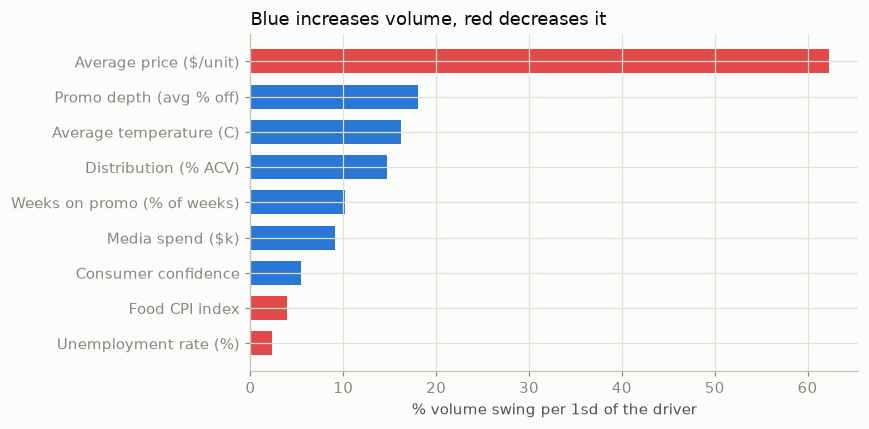

                      label  elasticity  log_sd  impact_pct  impact_share
     Average price ($/unit)      -1.715   0.363      62.319         0.438
    Promo depth (avg % off)       0.612   0.295      18.077         0.127
    Average temperature (C)       0.199   0.815      16.220         0.114
       Distribution (% ACV)       1.237   0.119      14.743         0.104
Weeks on promo (% of weeks)       0.294   0.348      10.217         0.072
           Media spend ($k)       0.123   0.741       9.083         0.064
        Consumer confidence       0.485   0.112       5.427         0.038
             Food CPI index      -0.520   0.076       3.957         0.028
      Unemployment rate (%)      -0.172   0.132       2.273         0.016


In [16]:
imp = m.importance()
fig, ax = plt.subplots(figsize=(8, 4))
cols = [config.POS if e > 0 else config.NEG for e in imp["elasticity"][::-1]]
ax.barh(imp["label"][::-1], imp["impact_pct"][::-1], color=cols, height=0.68)
ax.set_xlabel("% volume swing per 1sd of the driver")
ax.set_title("Blue increases volume, red decreases it", color=config.INK_PRIMARY, loc="left")
plt.tight_layout(); plt.show()
print(imp[["label", "elasticity", "log_sd", "impact_pct", "impact_share"]].round(3).to_string(index=False))

## 4.3 Decomposition — base plus incremental

`decompose()` splits predicted volume into a **base** (every driver sitting at its
category's historical mean) plus what each driver adds or removes.

Because the model is multiplicative, contributions compound rather than add:
$V = V_{\text{base}} \prod_j e^{\beta_j (\log x_j - \log \bar{x}_j)}$.
To report them as additive units, the total incremental volume is allocated by
each driver's share of the total log deviation — which makes the parts sum to the
whole exactly.

base + contributions == predicted: True  (max relative error 2.22e-16)

Beverages, most recent 3 months (units):
            predicted       base  avg_price  promo_depth  media_spend  avg_temp_c
date                                                                             
2026-04-01  1985727.0  2459539.0  -409236.0     -60666.0    -124727.0    148972.0
2026-05-01  3203090.0  2539185.0  -413818.0      73424.0     282136.0    335635.0
2026-06-01  3343997.0  2632499.0  -421248.0      14019.0     271573.0    504161.0


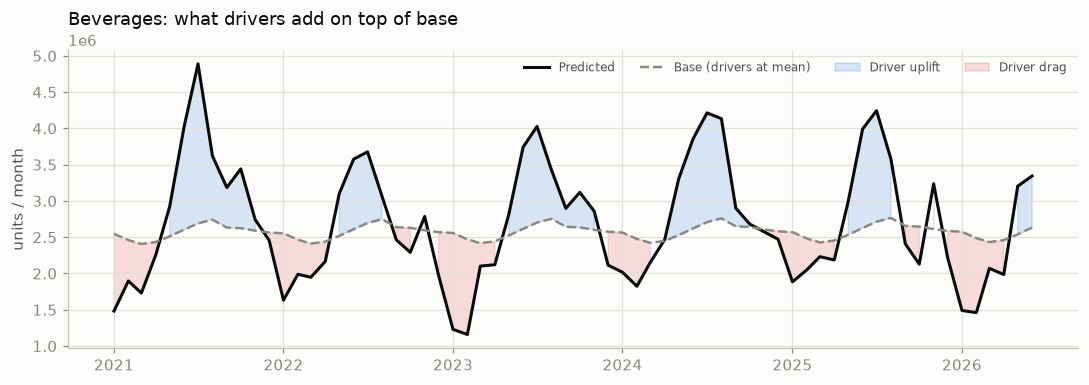

In [17]:
dec = m.decompose(panel)
recon = dec["base"] + dec[config.DRIVER_NAMES].sum(axis=1)
print(f"base + contributions == predicted: {np.allclose(recon, dec['predicted'])}  "
      f"(max relative error {np.abs(recon/dec['predicted'] - 1).max():.2e})\n")

d = dec[dec["category"] == "Beverages"].set_index("date")
print("Beverages, most recent 3 months (units):")
print(d[["predicted", "base", "avg_price", "promo_depth", "media_spend", "avg_temp_c"]].tail(3).round(0).to_string())

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(d.index, d["predicted"], color=config.INK_PRIMARY, lw=2, label="Predicted")
ax.plot(d.index, d["base"], color=config.INK_MUTED, lw=1.6, ls="--", label="Base (drivers at mean)")
ax.fill_between(d.index, d["base"], d["predicted"], where=d["predicted"] >= d["base"],
                color=BLUE, alpha=0.18, label="Driver uplift")
ax.fill_between(d.index, d["base"], d["predicted"], where=d["predicted"] < d["base"],
                color=config.NEG, alpha=0.18, label="Driver drag")
ax.set_ylabel("units / month"); ax.legend(frameon=False, ncol=4, fontsize=8)
ax.set_title("Beverages: what drivers add on top of base", color=config.INK_PRIMARY, loc="left")
plt.tight_layout(); plt.show()

---
# Part 5 — The scenario engine

`src/scenario.py` is deliberately thin. A scenario is just *"the Prophet forecast,
multiplied"* — there is no second model. Three steps:

1. `apply_adjustments` — scale the forecast driver paths by the slider %
2. `_predict_future` — prepend history, predict, slice back to the future rows
3. attribute the resulting delta across drivers

## 5.1 Applying the sliders

In [18]:
adj = {"avg_price": -10.0, "media_spend": 40.0}
bent = scen.apply_adjustments(driver_fc, adj)

chk = pd.DataFrame({
    "date": driver_fc["date"], "category": driver_fc["category"],
    "price_base": driver_fc["avg_price"], "price_scen": bent["avg_price"],
    "media_base": driver_fc["media_spend"], "media_scen": bent["media_spend"],
})
print(chk[chk["category"] == "Beverages"].head(4).round(2).to_string(index=False))
print(f"\nprice ratio {(bent['avg_price']/driver_fc['avg_price']).mean():.4f} (expect 0.90)")
print(f"media ratio {(bent['media_spend']/driver_fc['media_spend'].replace(0, np.nan)).mean():.4f} (expect 1.40)")

      date  category  price_base  price_scen  media_base  media_scen
2026-07-01 Beverages        3.50        3.15      957.60     1340.65
2026-08-01 Beverages        3.58        3.23      189.28      265.00
2026-09-01 Beverages        3.62        3.26      257.92      361.09
2026-10-01 Beverages        3.60        3.24      217.67      304.74

price ratio 0.9000 (expect 0.90)
media ratio 1.4000 (expect 1.40)


## 5.2 Why history is prepended before predicting

This is the subtle bit. Media adstock carries across the **seam** between the last
observed month and the first forecast month. If you predicted the future in
isolation, the carryover buffer would start at zero and July 2026 would look like
a category that had never advertised.

`_predict_future` concatenates history and future, applies adstock over the whole
sorted frame, then slices out the future rows.

In [19]:
fut = driver_fc[driver_fc["category"] == "Beverages"].sort_values("date")
hist_b = panel[panel["category"] == "Beverages"].sort_values("date")
lam = config.DRIVERS["media_spend"]["adstock"]

with_hist = features.geometric_adstock(
    np.concatenate([hist_b["media_spend"].to_numpy(), fut["media_spend"].to_numpy()]), lam)[len(hist_b):]
without = features.geometric_adstock(fut["media_spend"].to_numpy(), lam)

seam = pd.DataFrame({
    "month": fut["date"].dt.strftime("%Y-%m").to_numpy()[:6],
    "raw spend": fut["media_spend"].to_numpy()[:6],
    "adstock (history prepended)": with_hist[:6],
    "adstock (cold start)": without[:6],
})
seam["understated by"] = (1 - seam["adstock (cold start)"] / seam["adstock (history prepended)"]) * 100
print(seam.round(1).to_string(index=False))
print("\nThe cold-start error decays but is large in exactly the months a planner cares about most.")

  month  raw spend  adstock (history prepended)  adstock (cold start)  understated by
2026-07      957.6                       1412.0                 957.6            32.2
2026-08      189.3                        824.7                 620.2            24.8
2026-09      257.9                        629.0                 537.0            14.6
2026-10      217.7                        500.7                 459.3             8.3
2026-11      204.1                        429.5                 410.8             4.3
2026-12      175.0                        368.3                 359.9             2.3

The cold-start error decays but is large in exactly the months a planner cares about most.


## 5.3 Reproducing `run()` by hand

To show there's no hidden machinery, here is the whole calculation done manually
and checked against the shipped function.

In [20]:
cats = config.CATEGORIES
base_f = scen._predict_future(m, panel, driver_fc)
scen_f = scen._predict_future(m, panel, scen.apply_adjustments(driver_fc, adj))

manual_base = base_f["volume_pred"].sum()
manual_scen = scen_f["volume_pred"].sum()
res = scen.run(m, panel, driver_fc, adj, cats)

print(f"manual baseline {manual_base:>16,.0f}   run() {res['summary']['baseline_volume']:>16,.0f}")
print(f"manual scenario {manual_scen:>16,.0f}   run() {res['summary']['scenario_volume']:>16,.0f}")
print(f"delta           {manual_scen - manual_base:>16,.0f}   run() {res['summary']['delta_volume']:>16,.0f}")
print(f"\npct change {100*(manual_scen/manual_base - 1):+.3f}%   run() {res['summary']['delta_pct']:+.3f}%")

manual baseline      182,709,304   run()      182,709,304
manual scenario      227,623,420   run()      227,623,420
delta                 44,914,117   run()       44,914,117

pct change +24.582%   run() +24.582%


## 5.4 Attributing the delta back to drivers

The waterfall answers "where did that +24% come from?". For each driver the model
computes its log-space movement $\beta_j \, \Delta \log x_j$, then allocates the
*actual* total delta in proportion:

$$\Delta V_j = (V_{\text{scen}} - V_{\text{base}}) \times
\frac{\beta_j \Delta \log x_j}{\sum_k \beta_k \Delta \log x_k}$$

Allocating shares of the realised total — rather than summing each driver's
standalone effect — is what makes the parts reconcile exactly despite the
interaction between them.

In [21]:
dlog = {}
for n in config.DRIVER_NAMES:
    dlog[n] = float((m.elasticities[n] * (scen_f[f"l_{n}"] - base_f[f"l_{n}"])).mean())
dl = pd.Series(dlog)
dl = dl[dl.abs() > 1e-12]
print("Log-space movement per driver (mean over horizon):")
print(dl.round(5).to_string())
print(f"\nshare of total: \n{(dl / dl.sum()).round(4).to_string()}")

wf = res["waterfall"]
print(f"\nAllocated volume delta:\n{wf.to_string(index=False)}")
print(f"\nparts {wf['delta_volume'].sum():,.0f}  vs  total {res['summary']['delta_volume']:,.0f}  "
      f"-> reconciles: {np.isclose(wf['delta_volume'].sum(), res['summary']['delta_volume'])}")

Log-space movement per driver (mean over horizon):
avg_price      0.18068
media_spend    0.03940

share of total: 
avg_price      0.821
media_spend    0.179

Allocated volume delta:
     driver                  label  delta_volume  delta_pct
  avg_price Average price ($/unit)  3.692088e+07  20.207445
media_spend       Media spend ($k)  7.993234e+06   4.374837

parts 44,914,117  vs  total 44,914,117  -> reconciles: True


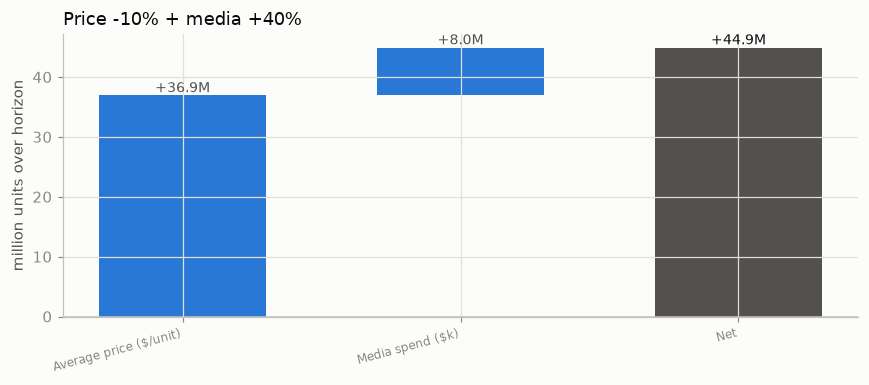

In [22]:
fig, ax = plt.subplots(figsize=(8, 3.6))
vals = wf["delta_volume"].to_numpy() / 1e6
labels = wf["label"].tolist()
cum = np.concatenate([[0], np.cumsum(vals)[:-1]])
for i, (lab, v, base_) in enumerate(zip(labels, vals, cum)):
    ax.bar(i, v, bottom=base_, color=config.POS if v > 0 else config.NEG, width=0.6)
    ax.annotate(f"{v:+.1f}M", (i, base_ + v), ha="center", fontsize=9,
                va="bottom" if v > 0 else "top", color=config.INK_SECONDARY)
ax.bar(len(vals), vals.sum(), color=config.INK_SECONDARY, width=0.6)
ax.annotate(f"{vals.sum():+.1f}M", (len(vals), vals.sum()), ha="center", va="bottom",
            fontsize=9, color=config.INK_PRIMARY)
ax.set_xticks(range(len(labels)+1)); ax.set_xticklabels(labels + ["Net"], rotation=15, ha="right", fontsize=8)
ax.axhline(0, color="#c3c2b7", lw=1); ax.set_ylabel("million units over horizon")
ax.set_title("Price -10% + media +40%", color=config.INK_PRIMARY, loc="left")
plt.tight_layout(); plt.show()

## 5.5 Response curves

Sweeping one driver across its slider range traces the response curve. In a
log-log model this is a power function, not a line — which is the whole point.
The curve is visibly asymmetric: a 20% price *rise* costs more volume than a 20%
price *cut* gains.

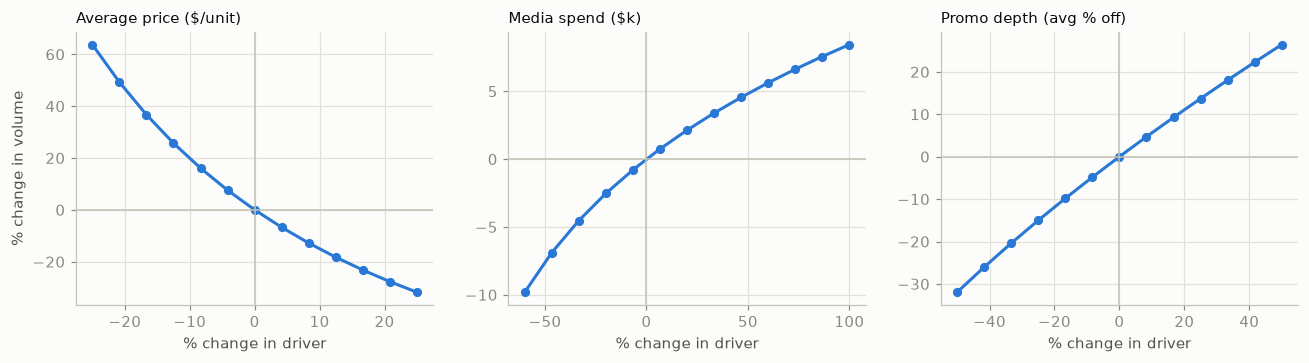

price -20% -> +46.62% volume
price +20% -> -26.85% volume     (asymmetric: -19.77pp)


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, d in zip(axes, ["avg_price", "media_spend", "promo_depth"]):
    lo_, hi_ = config.DRIVERS[d]["slider"]
    grid = np.linspace(lo_, hi_, 13)
    ys = [scen.run(m, panel, driver_fc, {d: float(p)}, cats)["summary"]["delta_pct"] for p in grid]
    ax.plot(grid, ys, "o-", color=BLUE, lw=2, ms=5)
    ax.axhline(0, color="#c3c2b7", lw=1); ax.axvline(0, color="#c3c2b7", lw=1)
    ax.set_title(config.DRIVERS[d]["label"], color=config.INK_PRIMARY, fontsize=10, loc="left")
    ax.set_xlabel("% change in driver")
axes[0].set_ylabel("% change in volume")
plt.tight_layout(); plt.show()

g = np.array([-20, 20])
yy = [scen.run(m, panel, driver_fc, {"avg_price": float(p)}, cats)["summary"]["delta_pct"] for p in g]
print(f"price -20% -> {yy[0]:+.2f}% volume")
print(f"price +20% -> {yy[1]:+.2f}% volume     (asymmetric: {abs(yy[1])-abs(yy[0]):+.2f}pp)")

---
# Part 6 — A worked scenario

Putting the whole chain together: a defensive plan — hold price, push distribution
and media — against a macro backdrop that deteriorates.

Levers:
  Average price ($/unit)             +3.0%
  Distribution (% ACV)               +5.0%
  Media spend ($k)                  +50.0%
  Promo depth (avg % off)           -15.0%
  Consumer confidence                -8.0%
  Unemployment rate (%)             +12.0%

baseline   182.71M units over 18 months
scenario   166.07M units
delta      -16.64M  (-9.11%)

             driver                   label  delta_volume  delta_pct
        promo_depth Promo depth (avg % off) -1.609599e+07  -8.809619
   distribution_acv    Distribution (% ACV)  1.051932e+07   5.757409
          avg_price  Average price ($/unit) -8.832935e+06  -4.834420
        media_spend        Media spend ($k)  8.224706e+06   4.501525
consumer_confidence     Consumer confidence -7.052964e+06  -3.860210
  unemployment_rate   Unemployment rate (%) -3.404390e+06  -1.863282


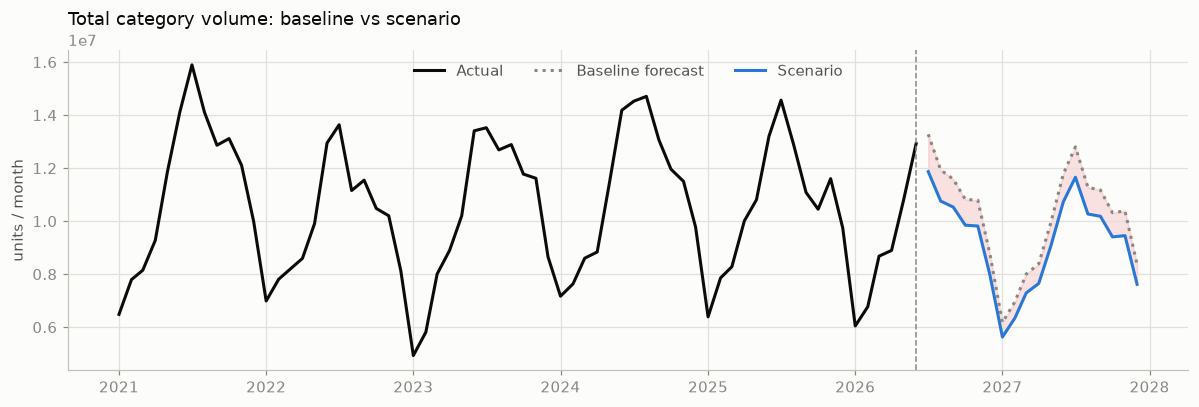

In [24]:
plan = {"avg_price": 3.0, "distribution_acv": 5.0, "media_spend": 50.0,
        "promo_depth": -15.0, "consumer_confidence": -8.0, "unemployment_rate": 12.0}

r = scen.run(m, panel, driver_fc, plan, cats)
s = r["summary"]
print("Levers:")
for k, v in plan.items():
    print(f"  {config.DRIVERS[k]['label']:32s} {v:+6.1f}%")
print(f"\nbaseline {s['baseline_volume']/1e6:>8.2f}M units over {config.FORECAST_MONTHS} months")
print(f"scenario {s['scenario_volume']/1e6:>8.2f}M units")
print(f"delta    {s['delta_volume']/1e6:>+8.2f}M  ({s['delta_pct']:+.2f}%)\n")
print(r["waterfall"].to_string(index=False))

paths = r["paths"].groupby("date", as_index=False)[["baseline", "scenario"]].sum()
hist_t = panel.groupby("date", as_index=False)["volume"].sum()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(hist_t["date"], hist_t["volume"], color=config.INK_PRIMARY, lw=2, label="Actual")
ax.plot(paths["date"], paths["baseline"], color=config.INK_MUTED, lw=2, ls=":", label="Baseline forecast")
ax.plot(paths["date"], paths["scenario"], color=BLUE, lw=2, label="Scenario")
ax.fill_between(paths["date"], paths["baseline"], paths["scenario"],
                color=BLUE if s["delta_volume"] > 0 else config.NEG, alpha=0.15)
ax.axvline(pd.Timestamp(config.HISTORY_END), color=config.INK_MUTED, ls="--", lw=1)
ax.set_ylabel("units / month"); ax.legend(frameon=False, ncol=3)
ax.set_title("Total category volume: baseline vs scenario", color=config.INK_PRIMARY, loc="left")
plt.tight_layout(); plt.show()

---
# Summary

| Step | Where | What it does |
|---|---|---|
| Adstock + log | `features.apply_adstock`, `features.log_features` | Media carryover, then to log space |
| Design matrix | `features.build_design` | log drivers + trend + category FE + month FE |
| CV folds | `model._time_folds` | Expanding window cut on **dates** — no leakage across a panel |
| Fit | `model.SignedRidge` | Bounded least squares on the ridge-augmented system |
| Elasticities | `model.fit` | `coef / scaler.scale_` — read straight off the log-driver columns |
| Ranking | `model.importance` | `|beta| x sd(log x)` — % swing per 1sd |
| Decomposition | `model.decompose` | Base + per-driver incremental, reconciling exactly |
| Scenario | `scenario.run` | Bend forecast drivers, re-predict with history prepended, attribute delta |

**The three non-obvious decisions**, all of which came out of diagnosing something
that looked wrong:

1. **CV cut on dates, not rows** — a random split leaks macro conditions across
   categories within the same month.
2. **Sign constraints** — `l_cpi_food` correlates 0.963 with the trend (VIF 23.3)
   and is only weakly identified; below alpha ≈ 0.01 the unconstrained fit flips
   it positive. At the selected `alpha=0.05` the constraint does **not** bind
   (0 of 9 active) — it is insurance against that regime, not a live correction.
3. **History prepended before scenario prediction** — otherwise media adstock
   cold-starts at zero and July 2026 is understated by 32%.

**The main limitation** is in §3.5: pooling forces one elasticity per driver, and
Beverages and Household Care are poorly served by a shared temperature response.
Category interactions or a hierarchical model is the next step.